In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("./Stats_Information_Attitude.xlsx").dropna()
df.head()

,category,article_number,affect,judgement,appreciation,positive,negative,ambiguous,word_count
0,1.0,1.0,0.0,50.0,13.0,59.0,3.0,1.0,474.0
1,1.0,2.0,0.0,38.0,14.0,39.0,7.0,6.0,643.0
2,1.0,3.0,0.0,43.0,10.0,43.0,7.0,1.0,669.0
3,1.0,4.0,0.0,31.0,6.0,29.0,8.0,0.0,448.0
4,1.0,5.0,0.0,43.0,14.0,46.0,10.0,1.0,630.0


In [3]:
genders = ["Balanced", "Equal", "Genderless", "Man", "Woman"]  # category 1–5
gender_order = ["Balanced", "Woman", "Man", "Equal", "Genderless"]

In [4]:
df["gender"] = df["category"].apply(lambda c: genders[int(c) - 1])
df.head()

,category,article_number,affect,judgement,appreciation,positive,negative,ambiguous,word_count,gender
0,1.0,1.0,0.0,50.0,13.0,59.0,3.0,1.0,474.0,Balanced
1,1.0,2.0,0.0,38.0,14.0,39.0,7.0,6.0,643.0,Balanced
2,1.0,3.0,0.0,43.0,10.0,43.0,7.0,1.0,669.0,Balanced
3,1.0,4.0,0.0,31.0,6.0,29.0,8.0,0.0,448.0,Balanced
4,1.0,5.0,0.0,43.0,14.0,46.0,10.0,1.0,630.0,Balanced


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme("talk")

In [6]:
import numpy as np
from matplotlib.axes import Axes

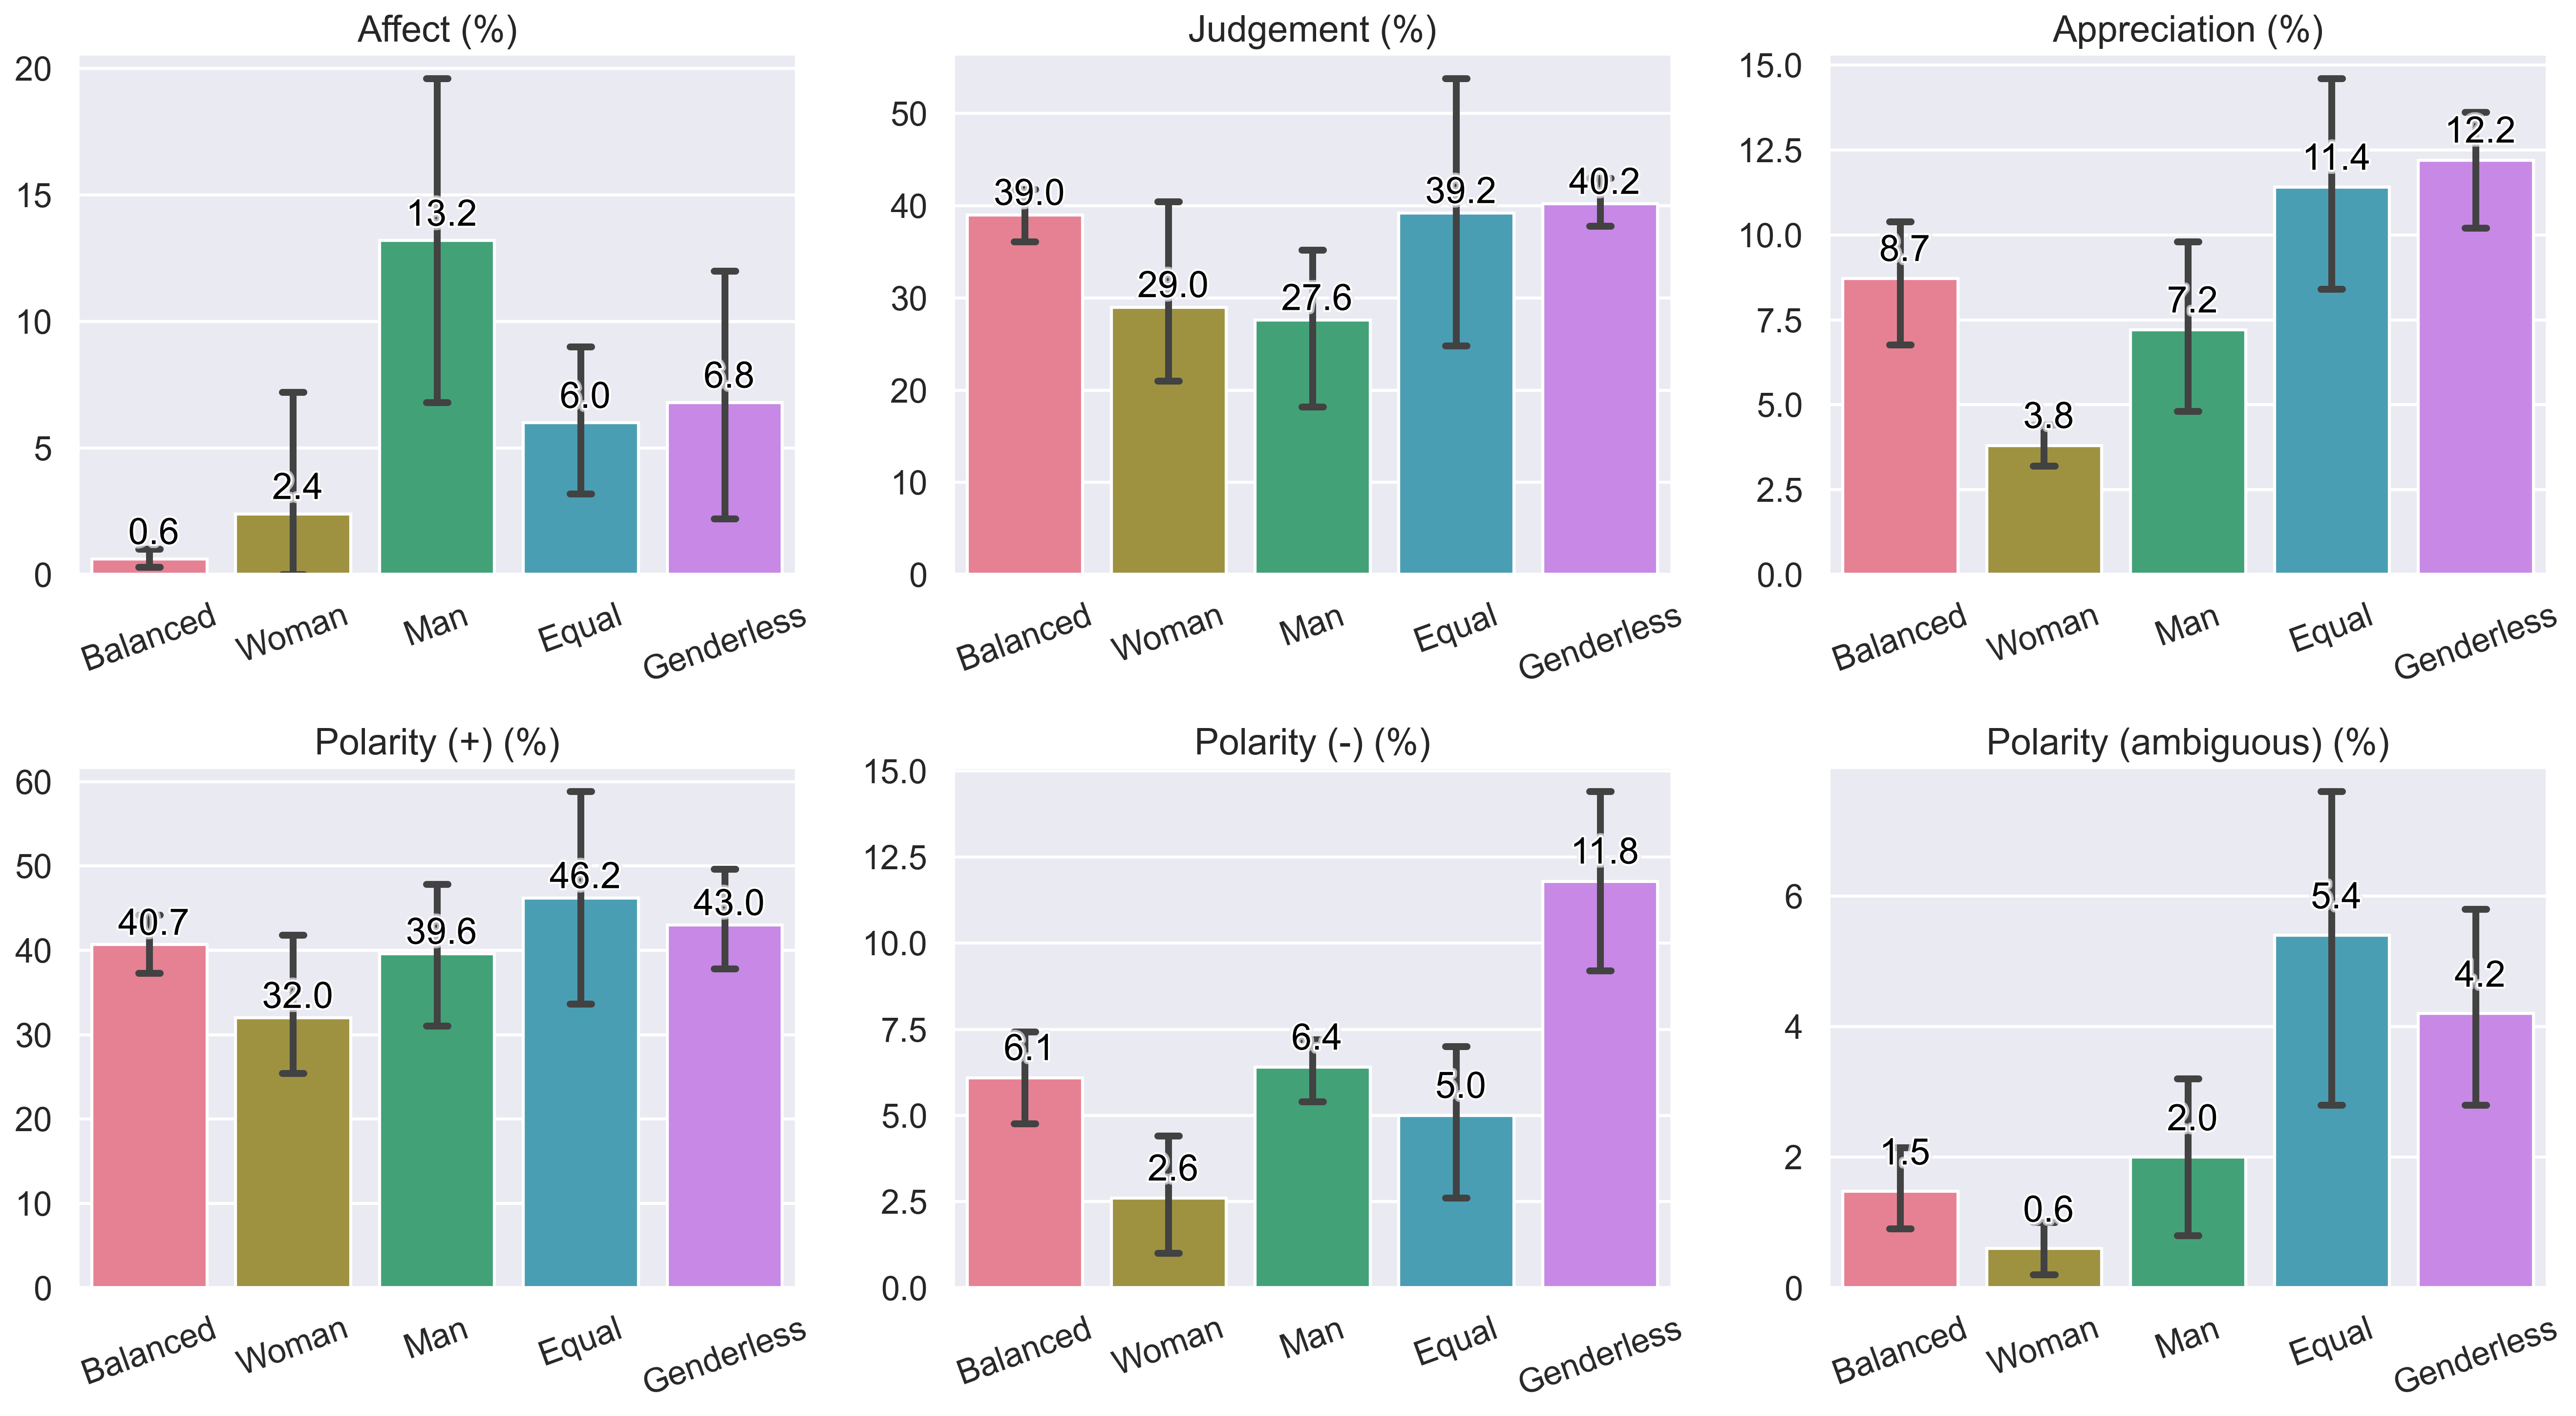

In [7]:
cols = ["affect", "judgement", "appreciation", "positive", "negative", "ambiguous"]

metric_labels = {
    "affect": "Affect (%)",
    "judgement": "Judgement (%)",
    "appreciation": "Appreciation (%)",
    "positive": "Polarity (+) (%)",
    "negative": "Polarity (-) (%)",
    "ambiguous": "Polarity (ambiguous) (%)",
}

palette = sns.color_palette("husl", n_colors=len(gender_order))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes: np.ndarray[Axes] = axes.flatten()

for ax, metric in zip(axes, cols):
    sns.barplot(
        data=df,
        x="gender",
        y=metric,
        order=gender_order,
        hue="gender",
        hue_order=gender_order,
        palette=palette,
        dodge=False,
        legend=False,
        capsize=0.15,
        ax=ax,
    )
    ax.set_title(metric_labels[metric])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20)
    for patch in ax.patches:
        height = patch.get_height()
        import matplotlib.patheffects as pe
        ax.text(
            patch.get_x() + patch.get_width() / 2 + 0.03,
            patch.get_y() + height + 0.3,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            color="black",
            path_effects=[
                pe.withStroke(linewidth=4, foreground="#eaeaf2", alpha=0.7),
                pe.withStroke(linewidth=2, foreground="white"),
            ],
        )

fig.set_dpi(300)
plt.tight_layout()
plt.savefig("./figures/attitude.png", dpi=300)